# 数据清洗

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 配置matplotlib中文显示
import platform

from matplotlib.pyplot import xlabel, ylabel
from rapidfuzz import fuzz, process
from sklearn.cluster import AgglomerativeClustering
system_name = platform.system()
import seaborn as sns
import matplotlib.dates as mdates
if system_name == 'Windows':
    # Windows系统
    plt.rcParams['font.family'] = ['SimHei']
elif system_name == 'Darwin':
    # macOS系统
    plt.rcParams['font.family'] = ['PingFang HK']
elif system_name == 'Linux':
    # Linux系统（可能需要根据具体发行版进行调整）
    plt.rcParams['font.family'] = ['DejaVu Sans']
else:
    # 其他系统或无法识别系统，默认字体
    plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

## 匹配表导入

In [3]:
fuel_match_table_fp = 'Resources/油品匹配表.xlsx'
fuel_match_table = pd.ExcelFile(fuel_match_table_fp)
print(fuel_match_table.sheet_names)

['Sheet1']


In [4]:
fuel_match_table_df = pd.read_excel(fuel_match_table_fp, sheet_name=0)
fuel_match_table_df.head()

,油品种类,最早出现日期,最晚出现日期,出现次数,标准油品种类
0,IC IC,2019-08-04,2022-02-11,242,ICIC
1,IC IC LLC,2023-04-24,2023-04-29,270,ICIC
2,ICIC,2023-11-22,2024-01-05,231,ICIC
3,ICIC LLC,2023-07-22,2023-07-22,1,ICIC
4,Other,2023-12-01,2024-05-31,12477,Other


In [5]:
equipment_match_table_fp = 'resources/设备名称表.xlsx'
equipment_match_table = pd.ExcelFile(equipment_match_table_fp)
print(equipment_match_table.sheet_names)

['匹配表']


In [6]:
equipment_match_table_df = pd.read_excel(equipment_match_table_fp, sheet_name=0)
equipment_match_table_df.head()

,设备名称,设备编号,公司,来源,最早出现日期,最晚出现日期,出现次数,标准设备编号,标准设备名称,标准公司名称,匹配情况
0,Шөнө,Шөнө,NaN,效率_Sheet1,2022-01-09,2022-01-31,23,AA#0001,忽略,NaN,1.0
1,设备种类 Техникийн төрөл,设备种类 Техникийн төрөл,公司 Компани,效率_Sheet1,2026-04-19,2026-04-19,1,AA#0001,忽略,NaN,1.0
2,夜班 Шөнө,夜班 Шөнө,NaN,效率_Sheet1,2022-04-01,2026-04-19,152,AA#0001,忽略,NaN,1.0
3,CAT D8 #09,CAT D8 #09,NaN,效率_Sheet1,2019-10-05,2019-10-05,2,AA#0001,忽略,NaN,1.0
4,CAT D8 #10,CAT D8 #10,NaN,效率_Sheet1,2019-10-05,2019-10-05,2,AA#0001,忽略,NaN,1.0


## 柴油消耗

### 基础分析

In [7]:
# import data
fuel_file_path = 'Resources/Fuel_合并.xlsx'
fuel = pd.ExcelFile(fuel_file_path)
print(fuel.sheet_names)

['油耗信息', '设备信息']


In [8]:
fuel_df = pd.read_excel(fuel_file_path, sheet_name=0)
fuel_df

,日期,班次,设备名称,设备编号,油品种类,油品消耗
0,2019-08-04,Night,TEREX TR100#56,HT0056,IC IC,476
1,2019-08-04,Night,TEREX TR100#58,HT0058,IC IC,462
2,2019-08-04,Night,TEREX TR100#59,HT0059,IC IC,451
3,2019-08-04,Night,TEREX TR100#60,HT0060,IC IC,454
4,2019-08-04,Night,TEREX TR100#61,HT0061,IC IC,502
...,...,...,...,...,...,...
222747,2026-04-30,Night,\nTOYOTA LANDCRUISER78 LV#1225,LV1225,Золотой /300007/,60
222748,2026-04-30,Night,9301УБР/ LV#1226 /TOYOTA /LAND 78/,LV1226,Золотой /300007/,30.84
222749,2026-04-30,Night,North Benz ST#137 /ST0137/,ST0137,Золотой /300007/,173.35
222750,2026-04-30,Night,North Benz ST#141,ST141,Золотой /300007/,350


### 合并

In [9]:
fuel_df = pd.merge(fuel_df, fuel_match_table_df[['油品种类','标准油品种类']], on='油品种类', how='left')
print(f'空值数量: {fuel_df["标准油品种类"].isnull().sum()}')
fuel_df['标准油品种类'].value_counts()

空值数量: 0


标准油品种类
Шунхлай /300008/             84496
Primary /300003/             55648
Синержи ойл /300009/         19721
Золотой /300007/             17409
НИК                          14475
Other                        12477
Сөүд монт форест /300012/     9050
Тод Өлзий /300010/            4053
Бусад /300001/                2966
Говь ойл газ /300013/         1607
ICIC                           744
Petrovis                        70
Петровис /300002/               36
Name: count, dtype: int64

In [10]:
(fuel_df.head())

,日期,班次,设备名称,设备编号,油品种类,油品消耗,标准油品种类
0,2019-08-04,Night,TEREX TR100#56,HT0056,IC IC,476,ICIC
1,2019-08-04,Night,TEREX TR100#58,HT0058,IC IC,462,ICIC
2,2019-08-04,Night,TEREX TR100#59,HT0059,IC IC,451,ICIC
3,2019-08-04,Night,TEREX TR100#60,HT0060,IC IC,454,ICIC
4,2019-08-04,Night,TEREX TR100#61,HT0061,IC IC,502,ICIC


In [11]:
# 对数据进行清洗
fuel_df['油品消耗'].dropna(inplace=True)
fuel_df['油品消耗'] = pd.to_numeric(fuel_df['油品消耗'], errors='coerce')

# 油品消耗基础统计数据
fuel_df['油品消耗'].describe()

count    222749.000000
mean       1080.453206
std        1550.878051
min           0.000000
25%         304.350000
50%         751.340000
75%        1728.000000
max       97730.000000
Name: 油品消耗, dtype: float64

<Axes: xlabel='油品消耗', ylabel='Count'>

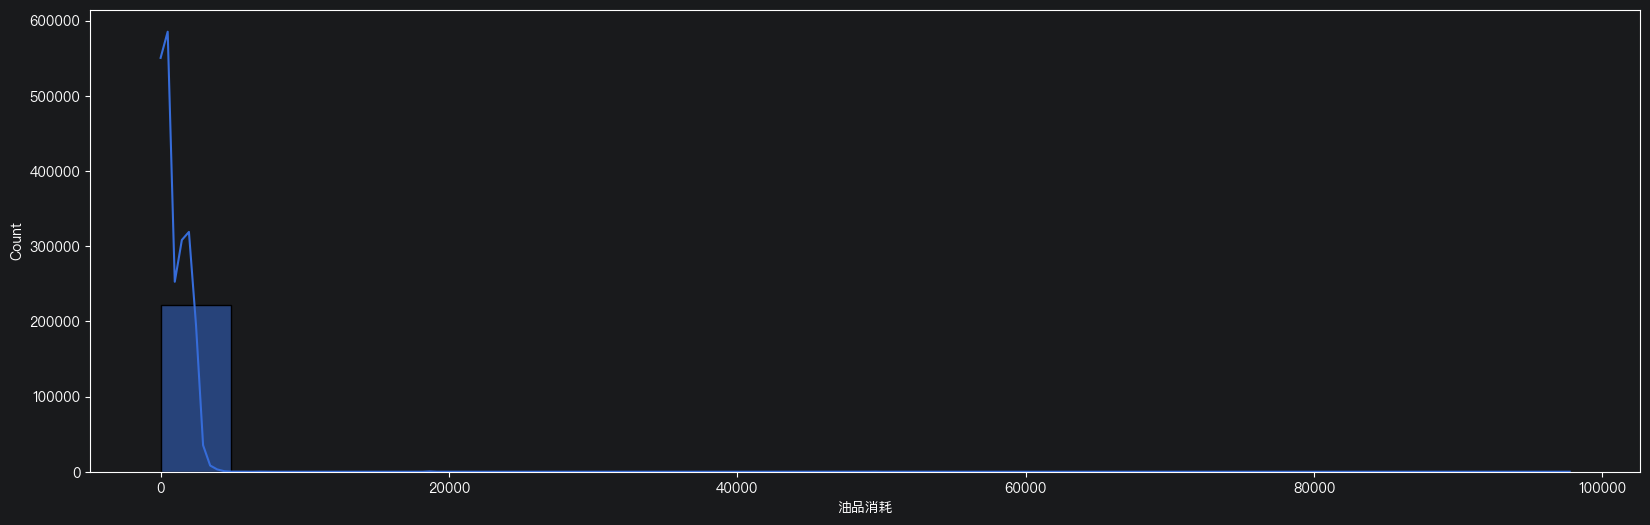

In [12]:
# 绘制标准正态分布直方图,使用sns.histplot
plt.figure(figsize=(20, 6))
sns.histplot(fuel_df['油品消耗'], kde=True, bins=20)

<Axes: xlabel='油品消耗', ylabel='Count'>

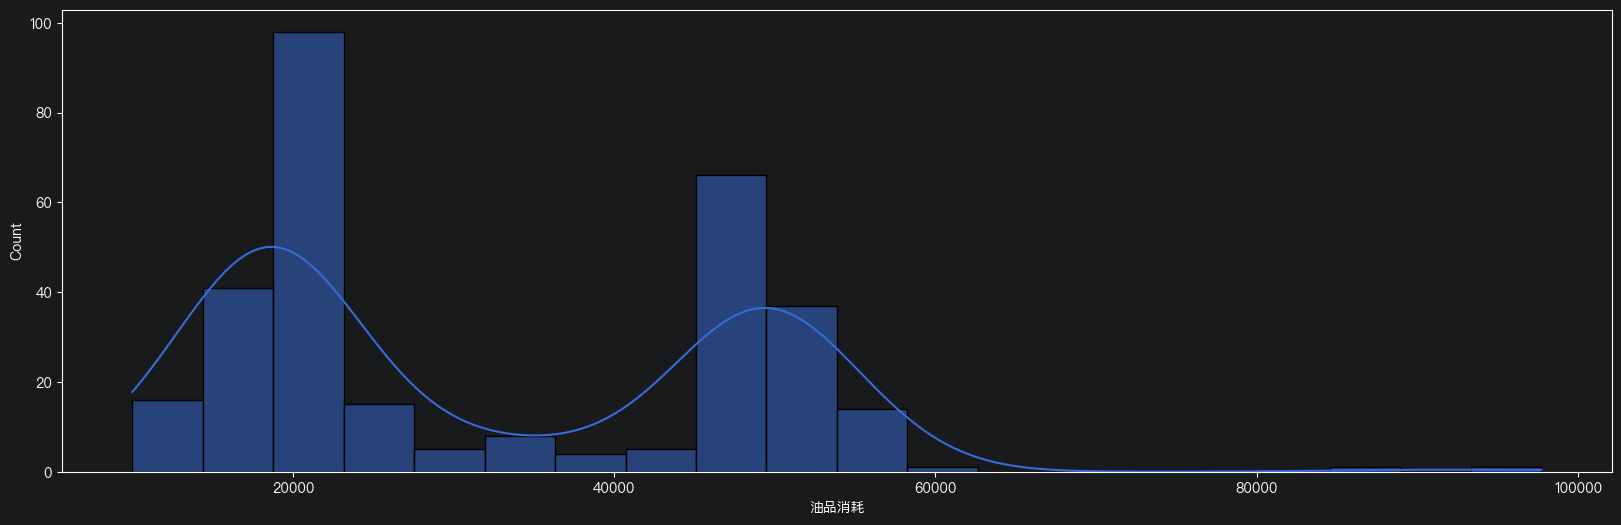

In [13]:
# 查看大于10000的油品消耗数据
plt.figure(figsize=(20, 6))
sns.histplot(fuel_df[fuel_df['油品消耗'] > 10000]['油品消耗'], kde=True, bins=20)
# fuel_df[fuel_df['油品消耗'] > 10000]

In [14]:
# 查看大于30000的油品消耗数据
# sns.histplot(fuel_df[fuel_df['油品消耗'] > 30000]['油品消耗'], kde=True, bins=20)
fuel_df[fuel_df['油品消耗'] > 30000]

,日期,班次,设备名称,设备编号,油品种类,油品消耗,标准油品种类
59790,2023-05-07,Day,ST330 MONNIS,ST#330,Цэций ойл,36820.0,Шунхлай /300008/
61853,2023-05-22,Day,ST330 MONNIS,ST#330,Цэций ойл,37640.0,Шунхлай /300008/
62251,2023-05-25,Day,ST330 MONNIS,ST#330,Цэций ойл,37640.0,Шунхлай /300008/
63266,2023-06-01,Day,ST330 MONNIS,ST#330,Цэций ойл,48240.0,Шунхлай /300008/
63569,2023-06-03,Day,ST330 MONNIS,ST#330,Цэций ойл,49600.0,Шунхлай /300008/
...,...,...,...,...,...,...,...
193908,2025-10-12,Day,ST330 MONNIS,ST#330,Тод Өлзий /300010/,52350.0,Тод Өлзий /300010/
194906,2025-10-19,Day,ST330 MONNIS,ST#330,Шунхлай /300008/,33020.0,Шунхлай /300008/
198660,2025-11-13,Day,ST330 MONNIS,ST#330,Сөүд монт форест /300012/,51200.0,Сөүд монт форест /300012/
199587,2025-11-19,Day,ST330 MONNIS,ST#330,Шунхлай /300008/,31000.0,Шунхлай /300008/


### 月统计

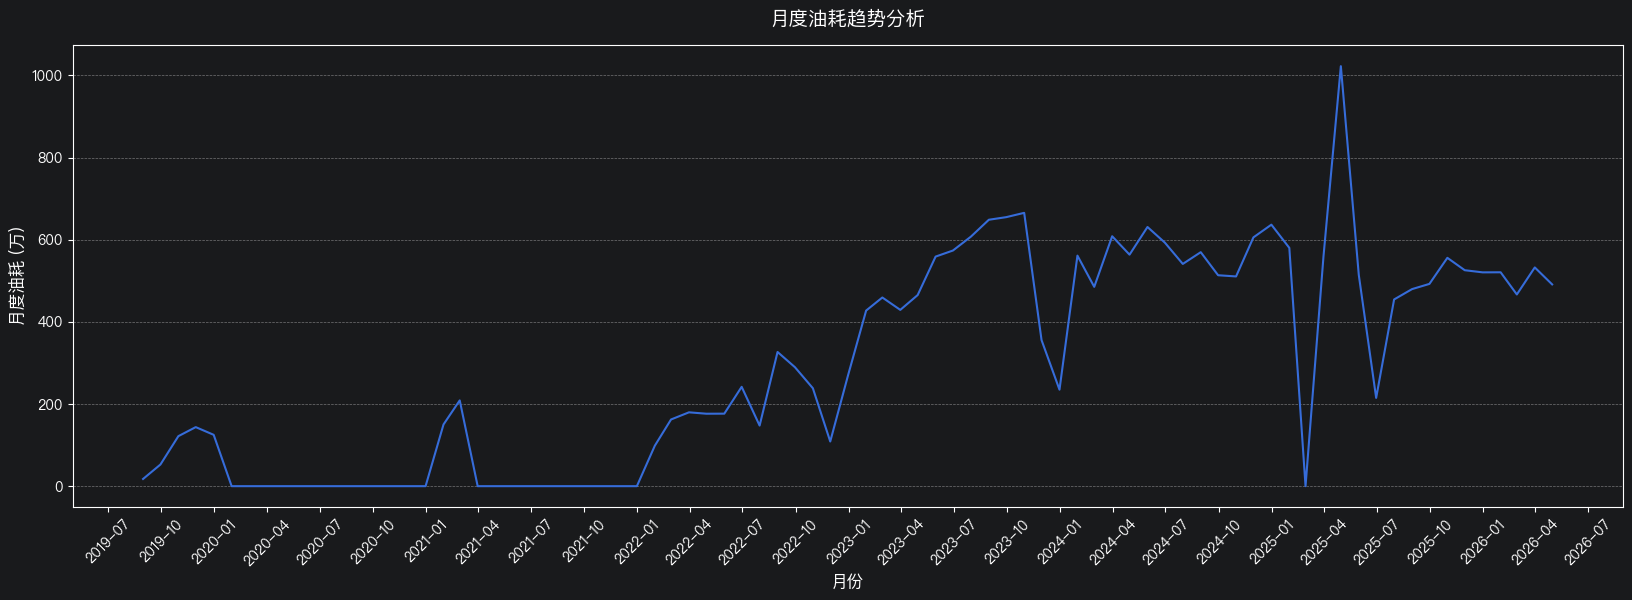

In [15]:
# 油品消耗月统计
fuel_df['日期'] = pd.to_datetime(fuel_df['日期'])
# 油品消耗月折线图
# 按月聚合
fig, ax = plt.subplots(figsize=(20, 6))
monthly_data = fuel_df.resample('ME',on='日期').油品消耗.sum()
sns.lineplot(data=monthly_data/10000)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))        # 主刻度设为每个月
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # 显示格式为 年-月
plt.xticks(rotation=45) # 旋转X轴标签防止重叠
# 开启网格线，方便对齐数据
ax.grid(True, linestyle='--', alpha=0.6, axis='y')
ax.set_xlabel('月份', fontsize=12)
ax.set_ylabel('月度油耗 (万)', fontsize=12)
ax.set_title('月度油耗趋势分析', fontsize=14, pad=15)
plt.show()

### 分析油耗最大的一个月

In [28]:
# 找到最大值所在的年月
max_month = fuel_df.resample('ME',on='日期').油品消耗.sum().idxmax()
mask1 = fuel_df['日期'].dt.year == max_month.year
mask2 = fuel_df['日期'].dt.month == max_month.month
fuel_max_month = fuel_df[mask1 & mask2]
fuel_max_month

,日期,班次,设备名称,设备编号,油品种类,油品消耗,标准油品种类
161538,2025-04-01,Day,CAT-D9GC #174 /DZ#174/,DZ#174,Шунхлай /300008/,389.0,Шунхлай /300008/
161539,2025-04-01,Day,CAT D8T #168 /DZ168/,DZ0168,Шунхлай /300008/,211.0,Шунхлай /300008/
161540,2025-04-01,Day,CAT D8T #169 /DZ169/,DZ0169,Шунхлай /300008/,100.0,Шунхлай /300008/
161541,2025-04-01,Day,CAT D8T #170 /DZ170/,DZ0170,Шунхлай /300008/,166.0,Шунхлай /300008/
161542,2025-04-01,Day,CAT-D9GC #175 /DZ175/,DZ175,Шунхлай /300008/,425.0,Шунхлай /300008/
...,...,...,...,...,...,...,...
172373,2025-04-30,Night,JMC JX1033 LV#139/1215 /LV#139/1215/,LV#139/1215,Шунхлай /300008/,45.0,Шунхлай /300008/
172374,2025-04-30,Night,North Benz ST#137 /ST0137/,ST0137,Шунхлай /300008/,176.0,Шунхлай /300008/
172375,2025-04-30,Night,CAT834K#173 /WD0173/,WD0173,Шунхлай /300008/,621.0,Шунхлай /300008/
172376,2025-04-30,Night,TR100W#1209 /WT1209/,WT1209,Синержи ойл /300009/,570.0,Синержи ойл /300009/


In [29]:
fuel_df.to_excel('Resources/fuel.xlsx')

## 发动机数据导入

In [46]:
engine_df = pd.read_excel(fuel_file_path, sheet_name=1)
engine_df

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
0,2019-09-01,Day,TEREX TR100#58,HT0058,301.1,311,9.9
1,2019-09-01,Day,TEREX TR100#64,HT0064,307.7,307.7,0
2,2019-09-01,Day,NHL NTE240 #66,HT0066,64,64,0
3,2019-09-01,Day,NHL NTE240 #67,HT0067,62,62,0
4,2019-09-01,Day,NHL NTE240 #68,HT0068,66,66,0
...,...,...,...,...,...,...,...
627207,2026-04-30,Night,XDM100 XD#3130 /RENT/,XD#3130/1173,3632,3632,0
627208,2026-04-30,Night,XD#3133/1176,XD#3133/1176,8821,8821,0
627209,2026-04-30,Night,XDE120 XD#3134 /RENT/,XD#3134/1177,10234.8,10234.8,0
627210,2026-04-30,Night,XDE130 XD#3136 /RENT/,XD#3136/1179,3329.4,3329.4,0


In [47]:
print(engine_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 627212 entries, 0 to 627211
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   日期        627212 non-null  datetime64[us]
 1   班次        627212 non-null  str           
 2   设备名称      627150 non-null  object        
 3   设备编号      627212 non-null  object        
 4   发动机小时数开始  605031 non-null  object        
 5   发动机小时数结束  605088 non-null  object        
 6   运行小时数     626302 non-null  object        
dtypes: datetime64[us](1), object(5), str(1)
memory usage: 33.5+ MB
None


### 异常值清洗

In [48]:
engine_df['发动机小时数开始'].describe()

count     605031
unique     61143
top            0
freq        5567
Name: 发动机小时数开始, dtype: int64

In [49]:
#找到不是数字的发动机小时数开始数据
engine_df[~pd.to_numeric(engine_df['发动机小时数开始'], errors='coerce').notnull()]

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
981,2019-10-01,Day,SHANTUI SD32 #15 /19-р товчоо/,DZ0015,NaN,NaN,0
982,2019-10-01,Day,CAT D9#23,DZ0023,NaN,NaN,0
983,2019-10-01,Day,HEATER #04,HE004,NaN,NaN,0
999,2019-10-01,Day,NHL NTE240DC #71 /CHUU/ /CONT/,HT0071,NaN,NaN,0
1000,2019-10-01,Day,NHL NTE240DC #72 /CHUU/ /CONT/,HT0072,NaN,NaN,0
...,...,...,...,...,...,...,...
626998,2026-04-30,Night,MASTER BV500#05,HE0005,NaN,NaN,0
626999,2026-04-30,Night,MASTER BV500#06,HE0006,NaN,NaN,0
627106,2026-04-30,Night,GTL LT4000M5 LIGHTTOWER,LP0039,NaN,NaN,0
627111,2026-04-30,Night,AS4006 LP#48 /LP0048/,LP0048,NaN,NaN,0


In [50]:
converted = pd.to_numeric(engine_df['发动机小时数开始'], errors='coerce')
# 这意味着原值本身就是非数字类型的有效字符
mask = engine_df['发动机小时数开始'].notna() & converted.isna()
engine_df[mask]

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
151068,2023-05-07,Night,ST330 MONNIS,ST#330,ST#330,ST#330,NaN
151253,2023-05-08,Day,ST330 MONNIS,ST#330,ST#330,ST#330,NaN
151438,2023-05-08,Night,ST330 MONNIS,ST#330,ST#330,ST#330,NaN
151623,2023-05-09,Day,ST330 MONNIS,ST#330,ST#330,ST#330,NaN
151808,2023-05-09,Night,ST330 MONNIS,ST#330,ST#330,ST#330,NaN
151994,2023-05-10,Day,ST330 MONNIS,ST#330,ST#330,ST#330,NaN
152180,2023-05-10,Night,ST330 MONNIS,ST#330,ST#330,ST#330,NaN
152366,2023-05-11,Day,ST330 MONNIS,ST#330,ST#330,ST#330,NaN
152552,2023-05-11,Night,ST330 MONNIS,ST#330,ST#330,ST#330,NaN
152738,2023-05-12,Day,ST330 MONNIS,ST#330,ST#330,ST#330,NaN


In [51]:
# 删除非数字
engine_df = engine_df[~mask]

In [52]:
engine_df['发动机小时数开始'].describe()

count     605016
unique     61142
top            0
freq        5567
Name: 发动机小时数开始, dtype: int64

In [53]:
# 发动机小时数结束
engine_df['发动机小时数结束'].describe()

count     605074
unique     61155
top            0
freq        5518
Name: 发动机小时数结束, dtype: int64

In [54]:
#找到不是数字的发动机小时数结束数据
engine_df[~pd.to_numeric(engine_df['发动机小时数结束'], errors='coerce').notnull()]

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
981,2019-10-01,Day,SHANTUI SD32 #15 /19-р товчоо/,DZ0015,NaN,NaN,0
982,2019-10-01,Day,CAT D9#23,DZ0023,NaN,NaN,0
983,2019-10-01,Day,HEATER #04,HE004,NaN,NaN,0
999,2019-10-01,Day,NHL NTE240DC #71 /CHUU/ /CONT/,HT0071,NaN,NaN,0
1000,2019-10-01,Day,NHL NTE240DC #72 /CHUU/ /CONT/,HT0072,NaN,NaN,0
...,...,...,...,...,...,...,...
626998,2026-04-30,Night,MASTER BV500#05,HE0005,NaN,NaN,0
626999,2026-04-30,Night,MASTER BV500#06,HE0006,NaN,NaN,0
627106,2026-04-30,Night,GTL LT4000M5 LIGHTTOWER,LP0039,NaN,NaN,0
627111,2026-04-30,Night,AS4006 LP#48 /LP0048/,LP0048,NaN,NaN,0


In [55]:
# 1. 尝试转换为数字，无法转换的变为 NaN (errors='coerce')
converted = pd.to_numeric(engine_df['发动机小时数结束'], errors='coerce')
# 这意味着原值本身就是非数字类型的有效字符
mask = engine_df['发动机小时数结束'].notna() & converted.isna()
engine_df[mask]

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
150883,2023-05-07,Day,ST330 MONNIS,ST#330,NaN,ST#330,NaN


In [56]:
# 删除非数字
engine_df = engine_df[~mask]
engine_df['发动机小时数结束'].describe()

count     605073
unique     61154
top            0
freq        5518
Name: 发动机小时数结束, dtype: int64

### 格式转换

In [57]:
engine_df['日期'] = pd.to_datetime(engine_df['日期'])
# 遇到nan为空
engine_df['发动机小时数开始'] = pd.to_numeric(engine_df['发动机小时数开始'], errors='coerce')
engine_df['发动机小时数结束'] = pd.to_numeric(engine_df['发动机小时数结束'], errors='coerce')
engine_df['运行小时数'] = engine_df['发动机小时数结束'] - engine_df['发动机小时数开始']
engine_df

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
0,2019-09-01,Day,TEREX TR100#58,HT0058,301.1,311.0,9.9
1,2019-09-01,Day,TEREX TR100#64,HT0064,307.7,307.7,0.0
2,2019-09-01,Day,NHL NTE240 #66,HT0066,64.0,64.0,0.0
3,2019-09-01,Day,NHL NTE240 #67,HT0067,62.0,62.0,0.0
4,2019-09-01,Day,NHL NTE240 #68,HT0068,66.0,66.0,0.0
...,...,...,...,...,...,...,...
627207,2026-04-30,Night,XDM100 XD#3130 /RENT/,XD#3130/1173,3632.0,3632.0,0.0
627208,2026-04-30,Night,XD#3133/1176,XD#3133/1176,8821.0,8821.0,0.0
627209,2026-04-30,Night,XDE120 XD#3134 /RENT/,XD#3134/1177,10234.8,10234.8,0.0
627210,2026-04-30,Night,XDE130 XD#3136 /RENT/,XD#3136/1179,3329.4,3329.4,0.0


In [58]:
engine_df['运行小时数'].describe()

count    6.043970e+05
mean     1.122934e+01
std      2.163983e+03
min     -1.031811e+06
25%      0.000000e+00
50%      0.000000e+00
75%      9.000000e+00
max      6.124920e+05
Name: 运行小时数, dtype: float64

<Axes: >

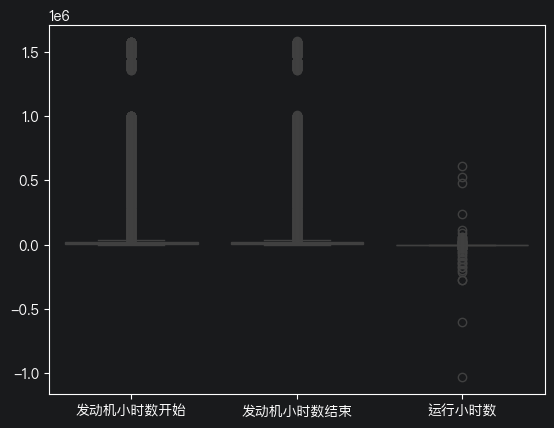

In [59]:
# 绘制箱线图
sns.boxplot(data=engine_df[engine_df['运行小时数']!=0])

In [60]:
print(f'小于0的运行小时数数量为：{len(engine_df[engine_df['运行小时数']<0])}')
engine_df[engine_df['运行小时数']<0]

小于0的运行小时数数量为：416


,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
31,2019-09-02,Day,NHL NTE240 #69,HT0069,86.0,78.0,-8.0
255,2019-09-10,Day,TEREX TR100#59,HT0059,463.8,463.2,-0.6
651,2019-09-22,Night,TEREX TR100 #57,HT0057,11.8,11.4,-0.4
714,2019-09-24,Day,TEREX TR100 #63,HT0063,19.2,11.6,-7.6
721,2019-09-24,Day,NHL NTE240 #70,HT0070,10.0,1.0,-9.0
...,...,...,...,...,...,...,...
604714,2026-03-16,Night,TEREX TR100 #1085,HT1085,342.9,333.0,-9.9
607972,2026-03-23,Day,GTL LT4000M5 LIGHTTOWER,LP0036,11750.0,20.0,-11730.0
614389,2026-04-05,Day,TOYOTA LANDCRUISER78 LV#125/1210 /LV#125/1210/,LV#125/1210,31360.0,3242.0,-28118.0
615345,2026-04-07,Day,GTL LT4000M5 LIGHTTOWER,LP0033,14563.0,47.0,-14516.0


### 运行小时数异常值处理

清理小于0的数

In [61]:
df = engine_df.copy()
df['运行小时数'] = df['运行小时数'].apply(lambda x: 0 if x<0 else x)
print(f'小于0的运行小时数数量为：{len(df[df['运行小时数']<0])}')
df[df['运行小时数']<0]

小于0的运行小时数数量为：0


,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数


小于12的占比为：79.40%
12-24的占比为：12.79%
大于24的占比为：4.17%


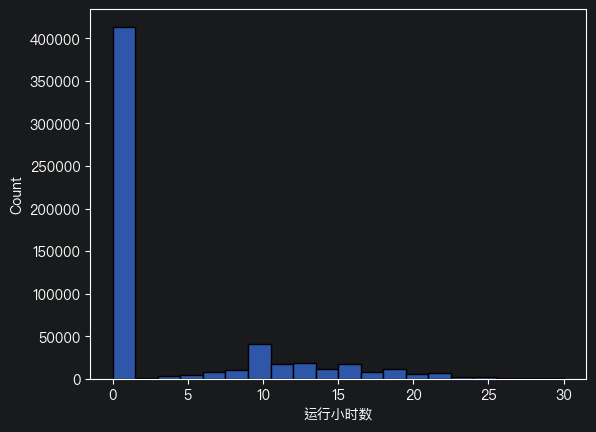

In [62]:
# 分箱， 20为间隔，0-800
bins = np.linspace(0,30,21)
# df_box = pd.cut(df['运行小时数'],bins=bins)
# df_box.value_counts()
sns.histplot(df['运行小时数'], bins=bins)
# 统计<12, 12-24, >24的占比
print(f'小于12的占比为：{len(df[df["运行小时数"]<12])/len(df):.2%}')
print(f'12-24的占比为：{len(df[(df["运行小时数"]>=12)&(df["运行小时数"]<24)])/len(df):.2%}')
print(f'大于24的占比为：{len(df[df["运行小时数"]>=24])/len(df):.02%}')

### 修复大于24的数

count    84436.000000
mean         8.955537
std          1.990427
min          1.100000
25%          8.000000
50%          9.400000
75%         10.000000
max         11.940000
Name: 运行小时数, dtype: float64


<Axes: xlabel='运行小时数', ylabel='Count'>

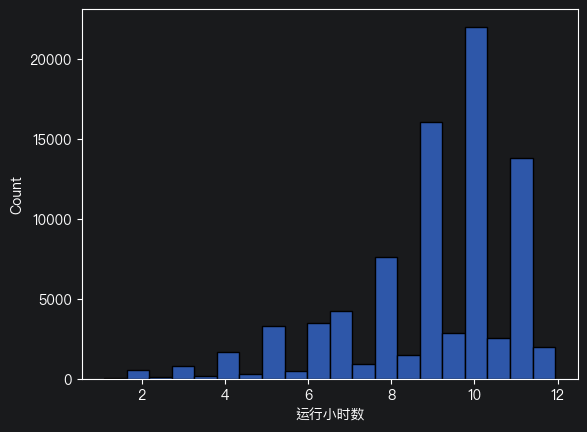

In [63]:
# 运行小时数小于12且大于1的值
mask1 = df['运行小时数']<12
mask2  = df['运行小时数']>1
df_less_12 = df[mask1 & mask2]
# df_less_12.groupby(['设备名称','设备编号']).mean()['运行小时数'].sort_values(ascending=False)
print(df_less_12['运行小时数'].describe())
# 绘图
sns.histplot(df_less_12['运行小时数'], bins=20)

In [64]:
print(f'大于24的运行小时数数量为：{len(df[df['运行小时数']>24])},占比为{len(df[df['运行小时数']>24])/len(df):.2%}')
df[df['运行小时数']>24].groupby(['设备名称','设备编号']).count()['运行小时数'].sort_values(ascending=False)

大于24的运行小时数数量为：24912,占比为3.97%


设备名称                                             设备编号       
TOYOTA LANDCRUISER79 LV#136/1204 /LV#136/1204/   LV#136/1204    400
SV133 /CONT/                                     SV133          364
ZaMine LV-176 /1331/                             LV0176         354
TOYOTA LANDCRUISER76 LV#111/1212 /LV#111/1212/   LV#111/1212    352
 TOYOTA LANDCRUISER79 LV#137/1205 /LV#137/1205/  LV#137/1205    342
                                                               ... 
SV147 /CONT/                                     SV#147           1
TEREX TR100 #64 /CHU/ /CONT/                     HT0064           1
NHL NTE240DC #72                                 HT0072           1
NHL NTE240DC #73                                 HT0073           1
CAT 14M#23                                       14M#23           1
Name: 运行小时数, Length: 370, dtype: int64

In [65]:
df[df['设备名称']=='TEREX TR100 #78 /CHU/ /CONT/']

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
1006,2019-10-01,Day,TEREX TR100 #78 /CHU/ /CONT/,HT0078,NaN,30.1,NaN
1047,2019-10-01,Night,TEREX TR100 #78 /CHU/ /CONT/,HT0078,30.1,35.0,4.9
1088,2019-10-02,Day,TEREX TR100 #78 /CHU/ /CONT/,HT0078,35.0,45.0,10.0
1129,2019-10-02,Night,TEREX TR100 #78 /CHU/ /CONT/,HT0078,45.0,55.2,10.2
1170,2019-10-03,Day,TEREX TR100 #78 /CHU/ /CONT/,HT0078,55.2,66.9,11.7
...,...,...,...,...,...,...,...
3319,2019-10-29,Night,TEREX TR100 #78 /CHU/ /CONT/,HT0078,550.3,561.0,10.7
3361,2019-10-30,Day,TEREX TR100 #78 /CHU/ /CONT/,HT0078,561.0,572.1,11.1
3403,2019-10-30,Night,TEREX TR100 #78 /CHU/ /CONT/,HT0078,572.1,581.7,9.6
3444,2019-10-31,Day,TEREX TR100 #78 /CHU/ /CONT/,HT0078,581.7,592.2,10.5


In [66]:
df[df['运行小时数']>720]

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
2244,2019-10-16,Day,SV-136,SV0136,132067.0,132790.0,723.0
2369,2019-10-18,Day,ATLASCOPCO CP#006,CP006,93.3,27573.0,27479.7
2871,2019-10-23,Night,SV-136,SV0136,132790.0,133660.0,870.0
3458,2019-10-31,Day,SV-136,SV0136,133660.0,134410.0,750.0
4768,2019-11-10,Day,TOYOTA LANDCRUISER79 #137,LV0137,5838.0,6592.0,754.0
...,...,...,...,...,...,...,...
623649,2026-04-23,Night,4205 УБП/ LV#1228 /TOYOTA / LAND 78/,LV1228,125400.0,126240.0,840.0
623932,2026-04-24,Day,2220 УЕС SV173,SV173,635523.0,636317.0,794.0
624403,2026-04-25,Day,ZTC250A ME#136,ME#136,3061.0,4006.0,945.0
626395,2026-04-29,Day,TOYOTA LANDCRUISER200 #184 /LV#184/,LV#184/1200,253189.0,254425.0,1236.0


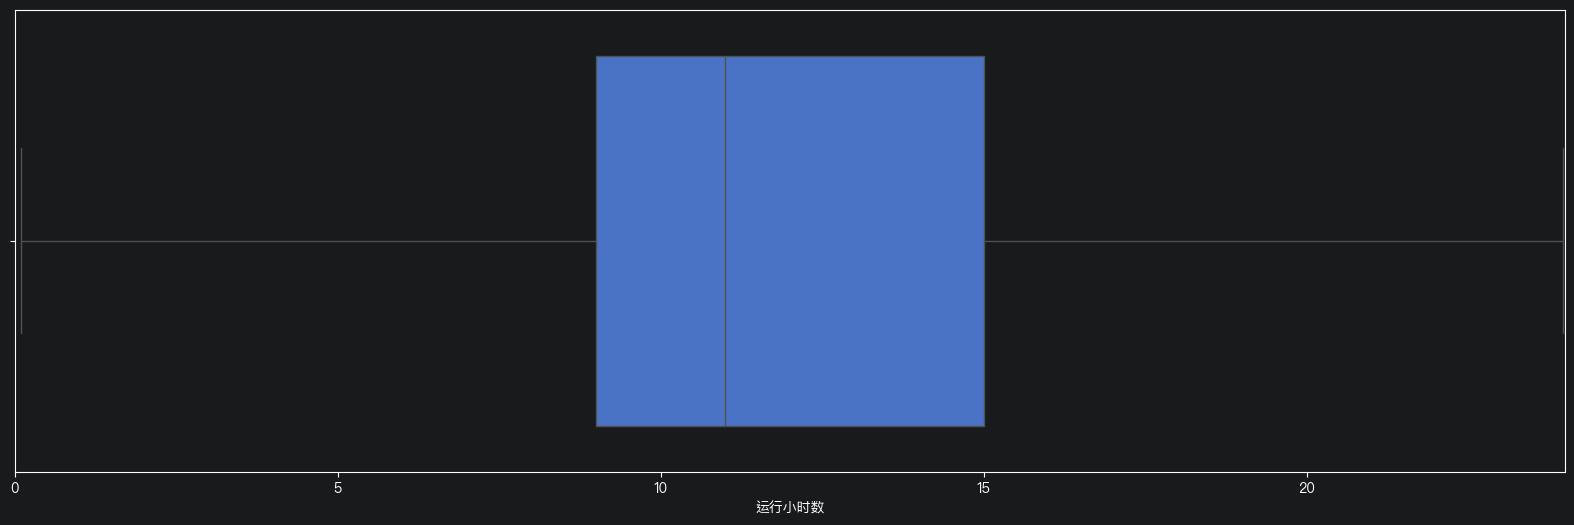

In [67]:
engine_df_cleaned = df.copy()
# 大于720值除以60， 使用apply
engine_df_cleaned['运行小时数'] = engine_df_cleaned['运行小时数'].apply(lambda x: x/60 if x>720 else x)
# 大于24的值，使用9覆盖
engine_df_cleaned['运行小时数'] = engine_df_cleaned['运行小时数'].apply(lambda x: 9 if x>=24 else x)
# 单位长度为10
fig,ax = plt.subplots(figsize=(20,6))
ax.set_xlim(0, 24)
sns.boxplot(data=engine_df_cleaned[engine_df_cleaned['运行小时数']!=0],x='运行小时数', ax=ax)
plt.show()
# 纵轴最大值

In [68]:
# 统计na个数
engine_df_cleaned['运行小时数'] = engine_df_cleaned['运行小时数'].fillna(0)

<Axes: xlabel='运行小时数', ylabel='Count'>

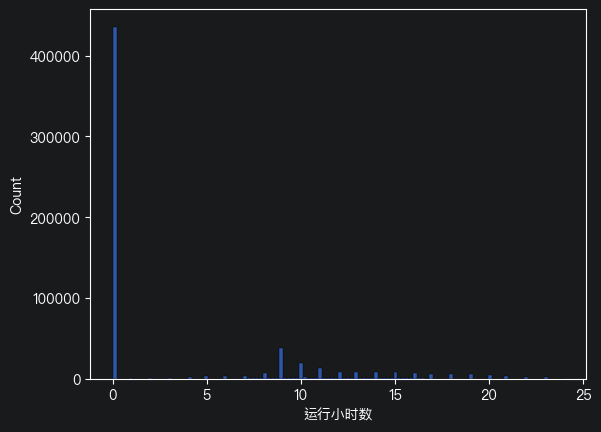

In [69]:
sns.histplot(engine_df_cleaned['运行小时数'])

<Axes: xlabel='运行小时数', ylabel='Count'>

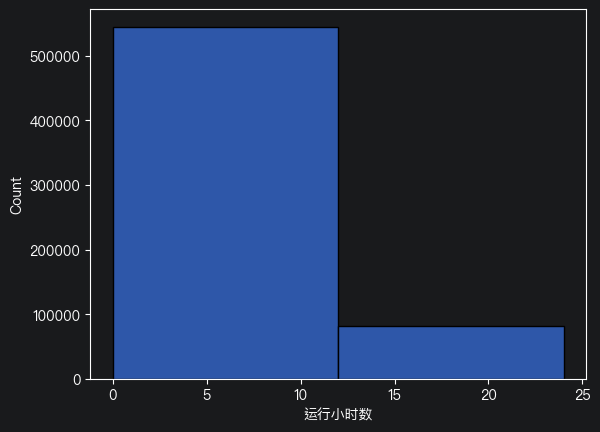

In [70]:
# 分箱，0-12, 12-24
bins = [0,12,24]
sns.histplot(engine_df_cleaned['运行小时数'], bins=bins)

统计0-12的运行小时数

In [71]:
# 大于等于0，且小于12的运行小时数
engine_hours = engine_df_cleaned[((engine_df_cleaned['运行小时数']>0) & (engine_df_cleaned['运行小时数']<12))]
engine_hours

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
0,2019-09-01,Day,TEREX TR100#58,HT0058,301.1,311.0,9.9
36,2019-09-02,Night,TEREX TR100#59,HT0059,321.0,330.0,9.0
59,2019-09-03,Day,NHL NTE240 #69,HT0069,93.0,103.0,10.0
63,2019-09-03,Night,TEREX TR100#58,HT0058,339.5,348.4,8.9
64,2019-09-03,Night,TEREX TR100#59,HT0059,342.0,349.0,7.0
...,...,...,...,...,...,...,...
627159,2026-04-30,Night,TOYOTA LANDCRUISER78 LV#1224,LV1224,162224.0,162891.0,9.0
627160,2026-04-30,Night,\nTOYOTA LANDCRUISER78 LV#1225,LV1225,178876.0,179121.0,9.0
627161,2026-04-30,Night,9301УБР/ LV#1226 /TOYOTA /LAND 78/,LV1226,66091.0,66247.0,9.0
627172,2026-04-30,Night,North Benz ST#137 /ST0137/,ST0137,21087.0,21120.0,9.0


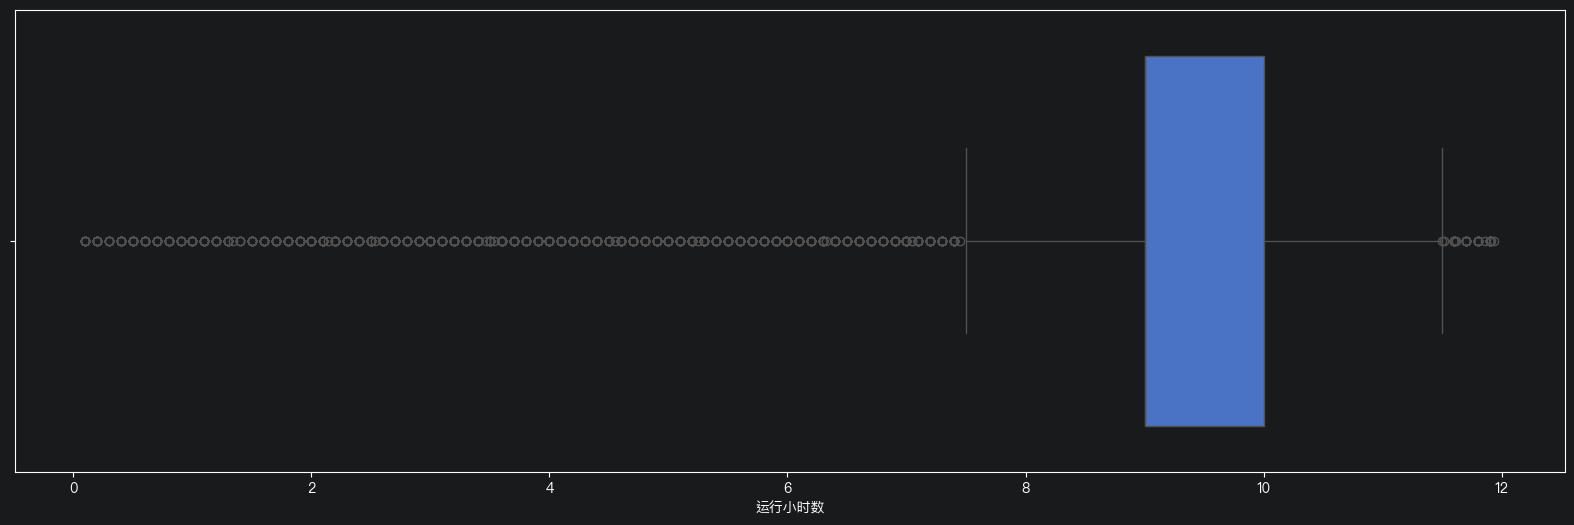

count    109136.000000
mean          8.931583
std           1.827184
min           0.100000
25%           9.000000
50%           9.000000
75%          10.000000
max          11.940000
Name: 运行小时数, dtype: float64


In [72]:
# 单位长度为10
fig,ax = plt.subplots(figsize=(20,6))
sns.boxplot(data=engine_hours,x='运行小时数', ax=ax)
plt.show()
print(engine_hours['运行小时数'].describe())
# 纵轴最大值

大于12的运行小时数的数据

In [73]:
engine_hours = engine_df_cleaned[engine_df_cleaned['运行小时数']>12]
engine_hours

,日期,班次,设备名称,设备编号,发动机小时数开始,发动机小时数结束,运行小时数
18,2019-09-01,Night,NHL NTE240 #69,HT0069,66.0,86.0,20.0
21,2019-09-02,Day,TEREX TR100#58,HT0058,311.0,327.0,16.0
22,2019-09-02,Day,TEREX TR100#59,HT0059,301.0,321.0,20.0
45,2019-09-02,Night,NHL NTE240 #69,HT0069,78.0,93.0,15.0
49,2019-09-03,Day,TEREX TR100#58,HT0058,327.0,339.5,12.5
...,...,...,...,...,...,...,...
627082,2026-04-30,Night,8743ММА/ NHL NTE240AC #1206 /NHL / NTE240AC/,HT1206,3391.0,3408.0,17.0
627083,2026-04-30,Night,8744ММА/ NHL NTE240AC #1207 /NHL / NTE240AC/,HT1207,3439.0,3460.0,21.0
627085,2026-04-30,Night,NHL NTE240 #1220,HT1220,2999.0,3016.0,17.0
627086,2026-04-30,Night,NHL NTE240 #1221,HT1221,3089.0,3110.0,21.0


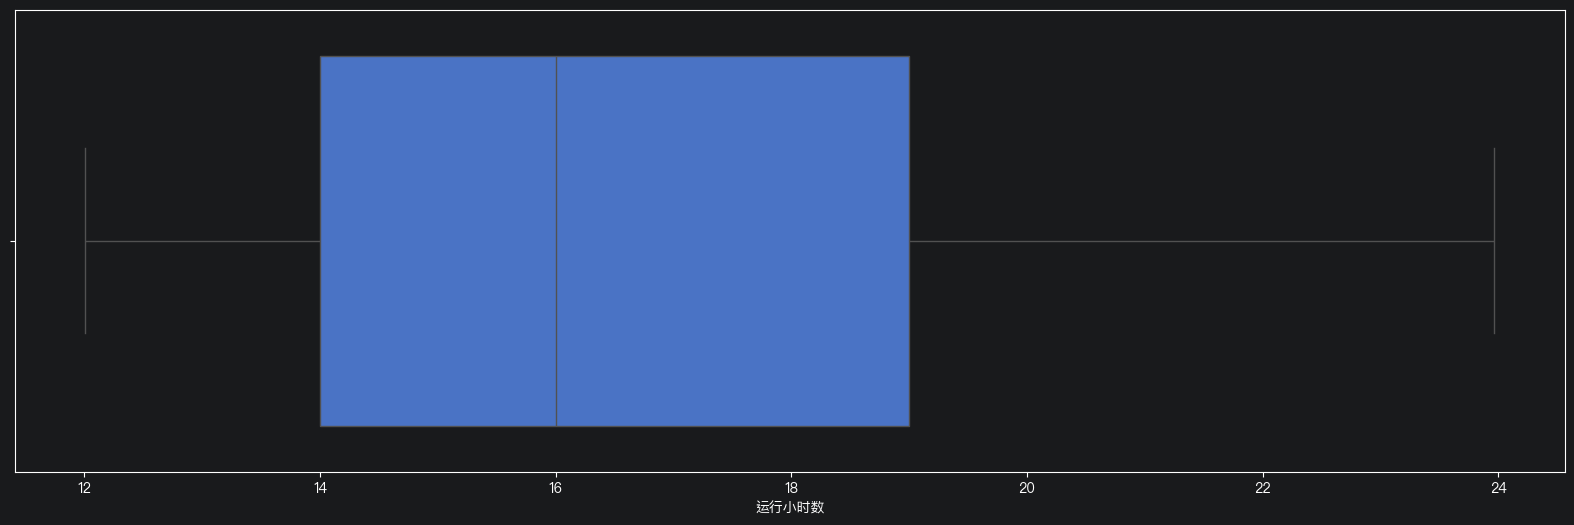

count    74329.000000
mean        16.521006
std          2.860757
min         12.010000
25%         14.000000
50%         16.000000
75%         19.000000
max         23.966667
Name: 运行小时数, dtype: float64


In [74]:
# 单位长度为10
fig,ax = plt.subplots(figsize=(20,6))
sns.boxplot(data=engine_hours,x='运行小时数', ax=ax)
plt.show()
print(engine_hours['运行小时数'].describe())
# 纵轴最大值

## 保存

In [75]:
engine_df_cleaned_fp = 'Resources/engine_cleaned.xlsx'
engine_df_cleaned.to_excel(engine_df_cleaned_fp,index=False)

# 效率

In [30]:
e_fp = 'Resources/效率_合并.xlsx'
e_table = pd.ExcelFile(e_fp)
print(e_table.sheet_names)

['Sheet1']


In [31]:
e_df = pd.read_excel(e_fp, sheet_name=0)
e_df.head()

,日期,班次,序号 Д/д,设备种类 Техникийн төрөл,公司 Компани,应运行分钟 Ажиллах мин,应运行小时数 Ажиллах мот цаг,停车/换班/\nСул Зогсолт /Ээлж солигдох /,转移 Шилжих\nхөдөлгөөн,挖机场地推土 /清理墙壁/\nУл талбай түрүүлэх/Ханын цэвэрлэгээ/,...,未计划/故障 Төлөвлөгөөт бус/эвдрэл,待命 Бэлэн байдалд,因天气：大风暴，雨，雪Цаг агаар: Хүчтэй салхи. Бороо.Цас,扬尘：洒水车不足 Тоосжилт: Усны машин хангалтгүй,排队/装水/ Дараалалд зогсох /Ус дүүргэх/,总产量生产运行分钟 Нийт бүтээлтэй ажилласан мин,因电力原因停车。/计划/Цахилгаанаас шалтгаалсан зогсолт ./Төлөвлөсөн/,因电力原因停车。/未计划/Цахилгаанаас шалтгаалсан зогсолт /Төлөвлөгөөт бус/,总产量生产运行小时 Нийт бүтээлтэй ажилласан цаг,注释 Тайлбар
0,2019-08-01,Day,1,LIEBHERR R996B #07,NaN,720,12,60,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,570,NaN,NaN,9.5,NaN
1,2019-08-01,Day,2,HITACHI EX3600 #01KH,NaN,720,12,60,30,30,...,NaN,30,NaN,NaN,NaN,510,NaN,NaN,8.5,NaN
2,2019-08-01,Day,3,HITACHI EX2600E #08,NaN,720,12,60,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,600,NaN,NaN,10,NaN
3,2019-08-01,Day,4,HITACHI EX2600E #03KH,NaN,720,12,60,210,20,...,NaN,NaN,NaN,NaN,NaN,370,NaN,NaN,6.166667,NaN
4,2019-08-01,Day,5,LIEBHERR R9350 #06,NaN,720,12,70,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,580,NaN,NaN,9.666667,NaN


## 清洗

In [35]:
e_df_clean = e_df.copy()
# 找到日期不是标准日期的值
e_df_clean['日期'] = pd.to_datetime(e_df_clean['日期'])
print(f'大小为{len(e_df_clean)}的行数')
e_df_clean = e_df_clean[e_df_clean['应运行小时数 Ажиллах мот цаг']==12]
print(f'大小为{len(e_df_clean)}的行数')

大小为416414的行数
大小为412345的行数


In [39]:
e_df_clean[e_df_clean['应运行小时数 Ажиллах мот цаг']!=12]

,日期,班次,序号 Д/д,设备种类 Техникийн төрөл,公司 Компани,应运行分钟 Ажиллах мин,应运行小时数 Ажиллах мот цаг,停车/换班/\nСул Зогсолт /Ээлж солигдох /,转移 Шилжих\nхөдөлгөөн,挖机场地推土 /清理墙壁/\nУл талбай түрүүлэх/Ханын цэвэрлэгээ/,...,未计划/故障 Төлөвлөгөөт бус/эвдрэл,待命 Бэлэн байдалд,因天气：大风暴，雨，雪Цаг агаар: Хүчтэй салхи. Бороо.Цас,扬尘：洒水车不足 Тоосжилт: Усны машин хангалтгүй,排队/装水/ Дараалалд зогсох /Ус дүүргэх/,总产量生产运行分钟 Нийт бүтээлтэй ажилласан мин,因电力原因停车。/计划/Цахилгаанаас шалтгаалсан зогсолт ./Төлөвлөсөн/,因电力原因停车。/未计划/Цахилгаанаас шалтгаалсан зогсолт /Төлөвлөгөөт бус/,总产量生产运行小时 Нийт бүтээлтэй ажилласан цаг,注释 Тайлбар


In [41]:
e_df_clean.columns

Index(['日期', '班次', '序号 Д/д',
       '设备种类                             Техникийн төрөл ', '公司 Компани',
       '应运行分钟 Ажиллах мин', '应运行小时数 Ажиллах мот цаг',
       '停车/换班/\nСул Зогсолт /Ээлж солигдох /', '转移 Шилжих\nхөдөлгөөн ',
       '挖机场地推土 /清理墙壁/\nУл талбай түрүүлэх/Ханын цэвэрлэгээ/',
       '等待装货 Ачилт хүлээх ', '爆破 Тэсэлгээ',
       '就餐。早晨休息时间\nХоолны цаг.Шөнийн цаг ', '柴油 Түлш\nFuel',
       '计划维修/润滑 Tөлөвлөсөн засвар / тосолгоо ',
       '未计划/故障 Төлөвлөгөөт бус/эвдрэл', '待命 Бэлэн байдалд',
       '因天气：大风暴，雨，雪Цаг агаар: Хүчтэй салхи. Бороо.Цас',
       '扬尘：洒水车不足 Тоосжилт: Усны машин хангалтгүй ',
       '排队/装水/ Дараалалд зогсох /Ус дүүргэх/',
       '总产量生产运行分钟 Нийт бүтээлтэй ажилласан мин',
       '因电力原因停车。/计划/Цахилгаанаас шалтгаалсан зогсолт ./Төлөвлөсөн/',
       '因电力原因停车。/未计划/Цахилгаанаас шалтгаалсан зогсолт /Төлөвлөгөөт бус/',
       '总产量生产运行小时 Нийт бүтээлтэй ажилласан цаг', '注释 Тайлбар'],
      dtype='str')

In [42]:
numeric_col = ['应运行分钟 Ажиллах мин', '应运行小时数 Ажиллах мот цаг',
       '停车/换班/\nСул Зогсолт /Ээлж солигдох /', '转移 Шилжих\nхөдөлгөөн ',
       '挖机场地推土 /清理墙壁/\nУл талбай түрүүлэх/Ханын цэвэрлэгээ/',
       '等待装货 Ачилт хүлээх ', '爆破 Тэсэлгээ',
       '就餐。早晨休息时间\nХоолны цаг.Шөнийн цаг ', '柴油 Түлш\nFuel',
       '计划维修/润滑 Tөлөвлөсөн засвар / тосолгоо ',
       '未计划/故障 Төлөвлөгөөт бус/эвдрэл', '待命 Бэлэн байдалд',
       '因天气：大风暴，雨，雪Цаг агаар: Хүчтэй салхи. Бороо.Цас',
       '扬尘：洒水车不足 Тоосжилт: Усны машин хангалтгүй ',
       '排队/装水/ Дараалалд зогсох /Ус дүүргэх/',
       '总产量生产运行分钟 Нийт бүтээлтэй ажилласан мин',
       '因电力原因停车。/计划/Цахилгаанаас шалтгаалсан зогсолт ./Төлөвлөсөн/',
       '因电力原因停车。/未计划/Цахилгаанаас шалтгаалсан зогсолт /Төлөвлөгөөт бус/',
       '总产量生产运行小时 Нийт бүтээлтэй ажилласан цаг']

# 转换为数字， Nan转为0
e_df_clean[numeric_col] = e_df_clean[numeric_col].apply(lambda x: pd.to_numeric(x, errors='coerce'))
e_df_clean[numeric_col] = e_df_clean[numeric_col].fillna(0)
e_df_clean

,日期,班次,序号 Д/д,设备种类 Техникийн төрөл,公司 Компани,应运行分钟 Ажиллах мин,应运行小时数 Ажиллах мот цаг,停车/换班/\nСул Зогсолт /Ээлж солигдох /,转移 Шилжих\nхөдөлгөөн,挖机场地推土 /清理墙壁/\nУл талбай түрүүлэх/Ханын цэвэрлэгээ/,...,未计划/故障 Төлөвлөгөөт бус/эвдрэл,待命 Бэлэн байдалд,因天气：大风暴，雨，雪Цаг агаар: Хүчтэй салхи. Бороо.Цас,扬尘：洒水车不足 Тоосжилт: Усны машин хангалтгүй,排队/装水/ Дараалалд зогсох /Ус дүүргэх/,总产量生产运行分钟 Нийт бүтээлтэй ажилласан мин,因电力原因停车。/计划/Цахилгаанаас шалтгаалсан зогсолт ./Төлөвлөсөн/,因电力原因停车。/未计划/Цахилгаанаас шалтгаалсан зогсолт /Төлөвлөгөөт бус/,总产量生产运行小时 Нийт бүтээлтэй ажилласан цаг,注释 Тайлбар
0,2019-08-01,Day,1,LIEBHERR R996B #07,NaN,720,12,60.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,570.0,0.0,0.0,9.500000,NaN
1,2019-08-01,Day,2,HITACHI EX3600 #01KH,NaN,720,12,60.0,30.0,30.0,...,0.0,30.0,0.0,0.0,0.0,510.0,0.0,0.0,8.500000,NaN
2,2019-08-01,Day,3,HITACHI EX2600E #08,NaN,720,12,60.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,600.0,0.0,0.0,10.000000,NaN
3,2019-08-01,Day,4,HITACHI EX2600E #03KH,NaN,720,12,60.0,210.0,20.0,...,0.0,0.0,0.0,0.0,0.0,370.0,0.0,0.0,6.166667,NaN
4,2019-08-01,Day,5,LIEBHERR R9350 #06,NaN,720,12,70.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,580.0,0.0,0.0,9.666667,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416409,2026-04-30,Night,142,XDE120 XD#1174,Normount,720,12,0.0,0.0,0.0,...,720.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN
416410,2026-04-30,Night,143,XDE120 XD#1175,Normount,720,12,0.0,0.0,0.0,...,720.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN
416411,2026-04-30,Night,144,XDE120 XD#1176,Normount,720,12,0.0,0.0,0.0,...,720.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN
416412,2026-04-30,Night,145,XDE120 XD#1177,Normount,720,12,0.0,0.0,0.0,...,720.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,NaN


In [44]:
e_df_clean.to_excel('Resources/效率_clean.xlsx', index=False)

In [76]:
p_fp = 'Resources/产量_合并.xlsx'
p_table = pd.ExcelFile(p_fp)
print(p_table.sheet_names)

['生产数据', '运行数据']


## 生产数据

In [77]:
production_df = pd.read_excel(p_fp, sheet_name=0)
production_df.head()

,日期,班次,矿卡名称,挖机名称,矿石类型,数量,产量
0,2019-08-17,Day,TEREX TR100 #56,CAT 390D #02,Хө,4.0,128.0
1,2019-08-17,Day,TEREX TR100 #57,CAT 390D #02,Хө,4.0,128.0
2,2019-08-17,Day,TEREX TR100 #58,CAT 390D #02,Хө,3.0,96.0
3,2019-08-17,Day,TEREX TR100 #59,CAT 390D #02,Хө,4.0,128.0
4,2019-08-17,Day,TEREX TR100 #60,CAT 390D #02,Хө,5.0,160.0


In [80]:
production_df['矿石类型'].value_counts()

矿石类型
Хө                 246468
Нү                  64433
Шг.х                 7954
oxid                 7575
И.А                  7499
共 Нийт               1491
Ш.Х                  1215
Б.н                   314
Хө BL                 241
Б.н.Inpit             138
Хө 装载数                 43
Хө 表土                  25
Б.н.Inpit.Inpit         1
Name: count, dtype: int64

In [93]:
production_df_clean = production_df.copy()
production_df_clean = production_df_clean[production_df_clean['矿石类型']!='共 Нийт']
production_df_clean['矿石类型'].value_counts()

矿石类型
Хө                 246468
Нү                  64433
Шг.х                 7954
oxid                 7575
И.А                  7499
Ш.Х                  1215
Б.н                   314
Хө BL                 241
Б.н.Inpit             138
Хө 装载数                 43
Хө 表土                  25
Б.н.Inpit.Inpit         1
Name: count, dtype: int64

In [94]:
# 统一矿石类型，使用字典进行匹配
dict_map = {'Хө BL':'Хө',
            'Хө 装载数':'Хө',
            'Хө 表土':'Хө',
            'Б.н.Inpit':'Б.н',
            'Б.н.Inpit.Inpit':'Б.н'}
production_df_clean['矿石类型'] = production_df_clean['矿石类型'].apply(lambda x: dict_map[x] if x in dict_map else x)
production_df_clean['矿石类型'].value_counts()

矿石类型
Хө      246777
Нү       64433
Шг.х      7954
oxid      7575
И.А       7499
Ш.Х       1215
Б.н        453
Name: count, dtype: int64

In [96]:
# 去除0
print(f'原大小为{len(production_df_clean)}的行数')
production_df_clean = production_df_clean[production_df_clean['数量']!=0]
print(f'现大小为{len(production_df_clean)}的行数')
production_df_clean

原大小为335896的行数
现大小为335896的行数


,日期,班次,矿卡名称,挖机名称,矿石类型,数量,产量
0,2019-08-17,Day,TEREX TR100 #56,CAT 390D #02,Хө,4.0,128.0
1,2019-08-17,Day,TEREX TR100 #57,CAT 390D #02,Хө,4.0,128.0
2,2019-08-17,Day,TEREX TR100 #58,CAT 390D #02,Хө,3.0,96.0
3,2019-08-17,Day,TEREX TR100 #59,CAT 390D #02,Хө,4.0,128.0
4,2019-08-17,Day,TEREX TR100 #60,CAT 390D #02,Хө,5.0,160.0
...,...,...,...,...,...,...,...
337392,2026-04-30,Night,NHL NTE240AC #1220,EX5600-6 #113,Хө,19.0,1615.0
337393,2026-04-30,Night,NHL NTE240AC #1221,EX5600-6 #113,Хө,19.0,1615.0
337394,2026-04-30,Night,NHL NTE240AC #1221,EX2600-6 #121,Хө,1.0,85.0
337395,2026-04-30,Night,NHL NTE240AC #1222,EX5600-6 #113,Хө,18.0,1530.0


In [98]:
production_df_clean[production_df_clean['产量']==0]

,日期,班次,矿卡名称,挖机名称,矿石类型,数量,产量
224415,2025-01-09,Night,BUCYRUS MT4400AC #1017,EX2600-6 #120,Хө,2.0,0.0
227512,2025-01-21,Day,BUCYRUS MT4400AC #1019,XE2000 EX#308/149,Хө,1.0,0.0
227513,2025-01-21,Day,BUCYRUS MT4400AC #1020,XE2000 EX#308/149,Хө,2.0,0.0
229737,2025-01-29,Day,BUCYRUS MT4400AC #1018,EX3600-6#112,Хө,2.0,0.0
229738,2025-01-29,Day,BUCYRUS MT4400AC #1018,EX2600-6 #120,Хө,10.0,0.0
229739,2025-01-29,Day,BUCYRUS MT4400AC #1019,EX3600-6#112,Хө,2.0,0.0
229740,2025-01-29,Day,BUCYRUS MT4400AC #1019,EX2600-6 #120,Хө,10.0,0.0
230215,2025-01-30,Night,BUCYRUS MT4400AC #1016,EX5600-6 #122,Хө,4.0,0.0
230216,2025-01-30,Night,BUCYRUS MT4400AC #1017,EX5600-6 #122,Хө,3.0,0.0
230217,2025-01-30,Night,BUCYRUS MT4400AC #1018,EX5600-6 #122,Хө,5.0,0.0


In [100]:
# 如果矿卡名称中包含MT4400AC，那么对应的产量等于数量乘以85
production_df_clean.loc[production_df_clean['矿卡名称'].str.contains('MT4400AC'),'产量'] = production_df_clean['数量']*85
production_df_clean[production_df_clean['矿卡名称'].str.contains('MT4400AC')]

,日期,班次,矿卡名称,挖机名称,矿石类型,数量,产量
3460,2019-10-11,Day,BUCYRUS MT4400AC #16,Hitachi 5600#11 /CHU/,Хө,1.0,85.0
7910,2019-11-15,Night,BUCYRUS MT4400AC #16,LIEBHERR R9350 #06,Хө,10.0,850.0
7911,2019-11-15,Night,BUCYRUS MT4400AC #16,Hitachi 5600#11 /CHU/,Хө,11.0,935.0
7912,2019-11-15,Night,BUCYRUS MT4400AC #17,LIEBHERR R9350 #06,Хө,9.0,765.0
7913,2019-11-15,Night,BUCYRUS MT4400AC #17,Hitachi 5600#11 /CHU/,Хө,12.0,1020.0
...,...,...,...,...,...,...,...
329040,2026-03-28,Day,BUCYRUS MT4400AC #1016,EX2600-6 #121,Хө,4.0,340.0
329041,2026-03-28,Day,BUCYRUS MT4400AC #1019,EX2600-6 #121,Хө,1.0,85.0
329598,2026-03-30,Day,BUCYRUS MT4400AC #1016,EX2600-6 #121,Хө,1.0,85.0
329727,2026-03-30,Night,BUCYRUS MT4400AC #1018,EX2600-6BH#133,Хө,2.0,170.0


In [102]:
production_df_clean[production_df_clean['产量']==0]

,日期,班次,矿卡名称,挖机名称,矿石类型,数量,产量


In [111]:
production_df_clean[production_df_clean['数量']>30]

,日期,班次,矿卡名称,挖机名称,矿石类型,数量,产量
189,2019-08-26,Day,TEREX TR100 #65,CAT 390D #02,Хө,31.0,992.0
24542,2022-02-19,Night,TEREX TR100A #1063,CAT992K#144,И.А,40.0,1280.0
24549,2022-02-19,Night,TEREX TR100A #1080,CAT992K#144,И.А,38.0,1216.0
24550,2022-02-19,Night,TEREX TR100A #1083,CAT992K#144,И.А,38.0,1216.0
24634,2022-02-21,Night,TEREX TR100A #1065,CAT992K#144,И.А,38.0,1216.0
...,...,...,...,...,...,...,...
330245,2026-04-02,Day,TEREX TR100A #1056,ЭТТ #004,И.А,31.0,1085.0
330571,2026-04-03,Day,Terex 60 #1188,LIEBHERR R976HD EX#152,И.А,33.0,726.0
330574,2026-04-03,Day,Terex 60 #323-1200,LIEBHERR R976HD EX#152,И.А,33.0,726.0
330575,2026-04-03,Day,Terex 60 #326-1201,LIEBHERR R976HD EX#152,И.А,32.0,704.0


count    335896.000000
mean          7.145727
std           5.184086
min           1.000000
25%           2.000000
50%           6.000000
75%          11.000000
max         100.000000
Name: 数量, dtype: float64


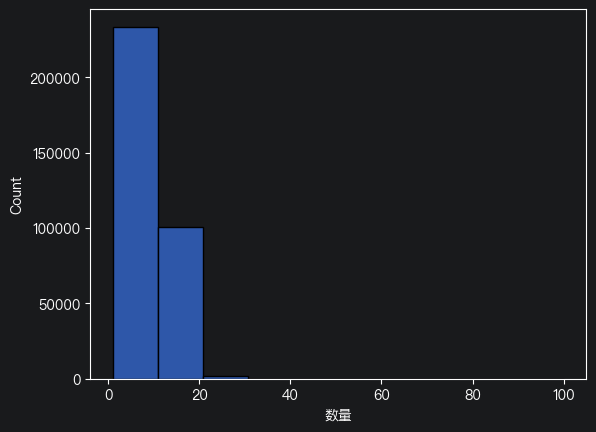

In [107]:
sns.histplot(production_df_clean['数量'], bins=10)
print(production_df_clean['数量'].describe())

### 保存

In [115]:
# 找到数量不为整数的值
production_df_clean[production_df_clean['数量']%1!=0]

,日期,班次,矿卡名称,挖机名称,矿石类型,数量,产量


In [112]:
production_df_clean.to_excel('Resources/产量_clean.xlsx',index=False)

## 运距

In [114]:
milage_df = pd.read_excel(p_fp, sheet_name=1)
milage_df.head()

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
0,2019-08-26,Day,TEREX TR100 #56 /CHU/,TTJV,131.4,131.4,0.0,1200.7,1200.7,0.0,0.0,NaN
1,2019-08-26,Day,TEREX TR100 #57 /CHU/,TTJV,188.3,197.8,9.5,1672.8,1769.0,96.2,14.0,NaN
2,2019-08-26,Day,TEREX TR100 #58 /CHU/,TTJV,186.1,195.0,8.9,1772.0,1877.0,105.0,16.0,NaN
3,2019-08-26,Day,TEREX TR100 #59 /CHU/,TTJV,189.9,195.2,5.3,1701.2,1752.0,50.8,7.0,NaN
4,2019-08-26,Day,TEREX TR100 #60 /CHU/,TTJV,191.5,201.4,9.9,1742.5,1839.0,96.5,15.0,NaN


In [116]:
milage_df

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
0,2019-08-26,Day,TEREX TR100 #56 /CHU/,TTJV,131.4,131.4,0.0,1200.7,1200.7,0.0,0.0,NaN
1,2019-08-26,Day,TEREX TR100 #57 /CHU/,TTJV,188.3,197.8,9.5,1672.8,1769.0,96.2,14.0,NaN
2,2019-08-26,Day,TEREX TR100 #58 /CHU/,TTJV,186.1,195.0,8.9,1772.0,1877.0,105.0,16.0,NaN
3,2019-08-26,Day,TEREX TR100 #59 /CHU/,TTJV,189.9,195.2,5.3,1701.2,1752.0,50.8,7.0,NaN
4,2019-08-26,Day,TEREX TR100 #60 /CHU/,TTJV,191.5,201.4,9.9,1742.5,1839.0,96.5,15.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
506817,2026-04-30,Night,TEREX TR100W #1209,Normount,13794.5,13794.5,0.0,0.0,0.0,0.0,0.0,Засвар
506818,2026-04-30,Night,TEREX TR100W #1210,Normount,16527.1,16527.1,0.0,0.0,0.0,0.0,0.0,Засвар
506819,2026-04-30,Night,WT #1211,Normount,3572.0,3579.3,7.3,0.0,0.0,0.0,0.0,худаг20-1 баяжуулах-2
506820,2026-04-30,Night,WT#1212,Normount,1137.5,1137.5,0.0,0.0,0.0,0.0,0.0,NaN


### 里程清洗

In [119]:
milage_df[milage_df['运行里程']<0]

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
96,2019-08-26,Night,TEREX TR100 #56 /CHU/,TTJV,131.4,0.0,-131.4,1200.7,0.0,-1200.7,0.0,NaN
97,2019-08-26,Night,TEREX TR100 #57 /CHU/,TTJV,207.0,9.2,-197.8,1867.3,98.3,-1769.0,49.0,NaN
98,2019-08-26,Night,TEREX TR100 #58 /CHU/,TTJV,205.3,10.3,-195.0,1984.3,107.3,-1877.0,58.0,NaN
99,2019-08-26,Night,TEREX TR100 #59 /CHU/,TTJV,205.0,9.8,-195.2,1847.2,95.2,-1752.0,40.0,NaN
100,2019-08-26,Night,TEREX TR100 #60 /CHU/,TTJV,210.5,9.1,-201.4,1933.3,94.3,-1839.0,40.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
430211,2025-11-11,Night,NHL NTE240DC #1008,TTJVCo,5215.1,0.0,-5215.1,79486.8,0.0,-79486.8,0.0,NaN
430663,2025-11-12,Night,NHL NTE240DC #1006,TTJVCo,8835.0,0.0,-8835.0,106270.7,0.0,-106270.7,0.0,NaN
430664,2025-11-12,Night,NHL NTE240DC #1007,TTJVCo,10243.1,0.0,-10243.1,116839.3,0.0,-116839.3,0.0,NaN
430665,2025-11-12,Night,NHL NTE240DC #1008,TTJVCo,5215.1,0.0,-5215.1,79486.8,0.0,-79486.8,0.0,NaN


In [189]:
milage_df_clean = milage_df[milage_df['运行里程']>=0]
milage_df_clean = milage_df_clean[milage_df_clean['趟数']>=0]
milage_df_clean

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
0,2019-08-26,Day,TEREX TR100 #56 /CHU/,TTJV,131.4,131.4,0.0,1200.7,1200.7,0.0,0.0,NaN
1,2019-08-26,Day,TEREX TR100 #57 /CHU/,TTJV,188.3,197.8,9.5,1672.8,1769.0,96.2,14.0,NaN
2,2019-08-26,Day,TEREX TR100 #58 /CHU/,TTJV,186.1,195.0,8.9,1772.0,1877.0,105.0,16.0,NaN
3,2019-08-26,Day,TEREX TR100 #59 /CHU/,TTJV,189.9,195.2,5.3,1701.2,1752.0,50.8,7.0,NaN
4,2019-08-26,Day,TEREX TR100 #60 /CHU/,TTJV,191.5,201.4,9.9,1742.5,1839.0,96.5,15.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
506817,2026-04-30,Night,TEREX TR100W #1209,Normount,13794.5,13794.5,0.0,0.0,0.0,0.0,0.0,Засвар
506818,2026-04-30,Night,TEREX TR100W #1210,Normount,16527.1,16527.1,0.0,0.0,0.0,0.0,0.0,Засвар
506819,2026-04-30,Night,WT #1211,Normount,3572.0,3579.3,7.3,0.0,0.0,0.0,0.0,худаг20-1 баяжуулах-2
506820,2026-04-30,Night,WT#1212,Normount,1137.5,1137.5,0.0,0.0,0.0,0.0,0.0,NaN


In [190]:
milage_df_clean['运行里程'].describe()

count    506522.000000
mean         56.472288
std         558.462084
min           0.000000
25%           0.000000
50%           0.000000
75%         132.000000
max      385384.900000
Name: 运行里程, dtype: float64

In [191]:
# 趟数等于0的，运行里程调整为0
milage_df_clean.loc[milage_df_clean['趟数']==0,'运行里程'] = 0
milage_df_clean

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
0,2019-08-26,Day,TEREX TR100 #56 /CHU/,TTJV,131.4,131.4,0.0,1200.7,1200.7,0.0,0.0,NaN
1,2019-08-26,Day,TEREX TR100 #57 /CHU/,TTJV,188.3,197.8,9.5,1672.8,1769.0,96.2,14.0,NaN
2,2019-08-26,Day,TEREX TR100 #58 /CHU/,TTJV,186.1,195.0,8.9,1772.0,1877.0,105.0,16.0,NaN
3,2019-08-26,Day,TEREX TR100 #59 /CHU/,TTJV,189.9,195.2,5.3,1701.2,1752.0,50.8,7.0,NaN
4,2019-08-26,Day,TEREX TR100 #60 /CHU/,TTJV,191.5,201.4,9.9,1742.5,1839.0,96.5,15.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
506817,2026-04-30,Night,TEREX TR100W #1209,Normount,13794.5,13794.5,0.0,0.0,0.0,0.0,0.0,Засвар
506818,2026-04-30,Night,TEREX TR100W #1210,Normount,16527.1,16527.1,0.0,0.0,0.0,0.0,0.0,Засвар
506819,2026-04-30,Night,WT #1211,Normount,3572.0,3579.3,7.3,0.0,0.0,0.0,0.0,худаг20-1 баяжуулах-2
506820,2026-04-30,Night,WT#1212,Normount,1137.5,1137.5,0.0,0.0,0.0,0.0,0.0,NaN


In [192]:
milage_df_clean[milage_df_clean['运行里程']>=300]

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
3350,2019-10-04,Night,TEREX TR100 #83 /CHU/,NaN,89.0,98.6,9.6,1252.0,1553.4,301.4,15.0,NaN
3381,2019-10-04,Night,TEREX TR100 #83 /CHU/,NaN,89.0,98.6,9.6,1252.0,1553.4,301.4,15.0,NaN
11189,2019-12-25,Night,TEREX TR100 #65 /CHU/,NaN,2462.6,2474.1,11.5,2168.0,2474.7,306.7,25.0,NaN
11209,2019-12-25,Night,TEREX TR100 #85 /CHU/,NaN,1659.8,1670.9,11.1,29230.0,29550.0,320.0,68.0,NaN
17289,2021-02-04,Night,NHL NTE240AC #1088 /CHU/,TTJV,2639.0,2649.0,10.0,39391.0,39754.0,363.0,16.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
495651,2026-04-06,Day,TEREX TR100A #1077,Normount,27189.0,27190.0,1.0,474942.0,475272.0,330.0,9.0,NaN
503020,2026-04-22,Night,TEREX TR100A #1077,Normount,27216.0,27216.0,0.0,480305.0,480641.0,336.0,6.0,NaN
503468,2026-04-23,Night,TEREX TR100A #1077,Normount,27216.0,27216.0,0.0,480641.0,481031.0,390.0,9.0,NaN
503531,2026-04-23,Night,NHL NTE240AC #1222,Normount,2845.0,2856.0,11.0,43533.0,43834.0,301.0,12.0,NaN


In [193]:
mask1 = milage_df_clean['运行里程']>=300
mask2 = milage_df_clean['趟数']<=4
milage_df_clean.loc[mask1 & mask2,'运行里程'] = 0

In [194]:
milage_df_clean['运行里程'] = milage_df_clean['运行里程'].apply(lambda x: 400 if x>400 else x)
milage_df_clean[milage_df_clean['运行里程']>=300]

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
3350,2019-10-04,Night,TEREX TR100 #83 /CHU/,NaN,89.0,98.6,9.6,1252.0,1553.4,301.4,15.0,NaN
3381,2019-10-04,Night,TEREX TR100 #83 /CHU/,NaN,89.0,98.6,9.6,1252.0,1553.4,301.4,15.0,NaN
11189,2019-12-25,Night,TEREX TR100 #65 /CHU/,NaN,2462.6,2474.1,11.5,2168.0,2474.7,306.7,25.0,NaN
11209,2019-12-25,Night,TEREX TR100 #85 /CHU/,NaN,1659.8,1670.9,11.1,29230.0,29550.0,320.0,68.0,NaN
17289,2021-02-04,Night,NHL NTE240AC #1088 /CHU/,TTJV,2639.0,2649.0,10.0,39391.0,39754.0,363.0,16.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
495651,2026-04-06,Day,TEREX TR100A #1077,Normount,27189.0,27190.0,1.0,474942.0,475272.0,330.0,9.0,NaN
503020,2026-04-22,Night,TEREX TR100A #1077,Normount,27216.0,27216.0,0.0,480305.0,480641.0,336.0,6.0,NaN
503468,2026-04-23,Night,TEREX TR100A #1077,Normount,27216.0,27216.0,0.0,480641.0,481031.0,390.0,9.0,NaN
503531,2026-04-23,Night,NHL NTE240AC #1222,Normount,2845.0,2856.0,11.0,43533.0,43834.0,301.0,12.0,NaN


In [195]:
milage_df_clean[milage_df_clean['运行里程']>=400]

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
148175,2023-10-11,Night,TEREX TR60 TR#3109,Normount,14413.9,14423.3,9.4,326870.0,327354.8,400.0,15.0,NaN
148181,2023-10-11,Night,TEREX TR60 TR#3127,Normount,11034.0,11043.2,9.2,247828.4,248334.4,400.0,15.0,NaN
148712,2023-10-13,Night,TEREX TR60 TR#3127,Normount,11070.1,11078.7,8.6,249082.3,249939.4,400.0,15.0,NaN
148972,2023-10-14,Night,TEREX TR60 TR#3109,Normount,14472.3,14481.0,8.7,328406.0,328825.9,400.0,16.0,NaN
185053,2024-02-28,Day,NHL NTE240AC #1072,Normount,15181.0,15192.0,11.0,229104.0,229504.0,400.0,15.0,NaN
235482,2024-07-12,Night,TEREX TR100A #1057,Normount,17435.8,17442.2,6.4,163133.0,163975.0,400.0,5.0,NaN
235558,2024-07-12,Night,NHL NTE240AC #1134,Normount,9827.0,9836.0,9.0,155262.0,155836.0,400.0,10.0,NaN
403207,2025-09-12,Night,TEREX TR100A #1058,Normount,23625.9,23634.0,8.1,16507.0,16907.0,400.0,5.0,NaN


<Axes: xlabel='运行里程', ylabel='Count'>

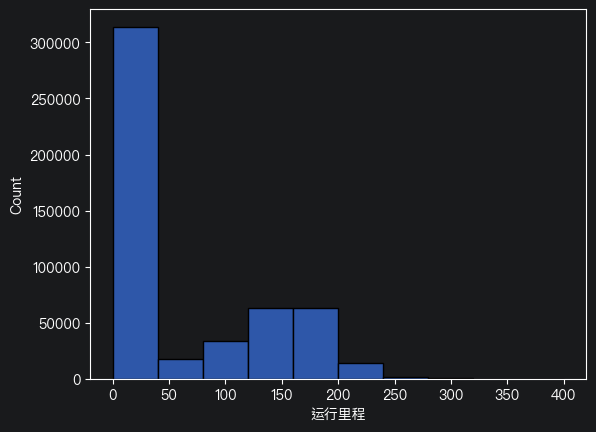

In [196]:
sns.histplot(milage_df_clean['运行里程'],  bins=10)

### 小时数

In [197]:
milage_df_clean[milage_df_clean['运行小时数']<0]

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
2127,2019-09-08,Night,CAT 992K #01KH,NaN,18076.5,0.0,-18076.5,0.0,0.0,0.0,0.0,NaN
2136,2019-09-08,Night,LIEBHERR L550 #03,TTJV,21738.5,0.0,-21738.5,0.0,0.0,0.0,0.0,NaN
2137,2019-09-08,Night,LIUGONG CLG855N #07,TTJV,15768.0,0.0,-15768.0,0.0,0.0,0.0,0.0,NaN
2144,2019-09-08,Night,LIEBHERR 764PR #04,ETT,12596.5,0.0,-12596.5,0.0,0.0,0.0,0.0,NaN
2148,2019-09-08,Night,SHANTUI SD52 #08,TTJV,5924.0,0.0,-5924.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
264157,2024-10-06,Night,TEREX TR100A #1080,Normount,17567.0,17564.0,-3.0,39.1,385424.0,0.0,0.0,NaN
333647,2025-03-23,Night,LIEBHERR R984C EX#148,Normount,32988.0,32979.0,-9.0,0.0,0.0,0.0,0.0,NaN
333678,2025-03-23,Night,TEREX TR60 SV#161,Monnis,18643.5,18638.8,-4.7,0.0,0.0,0.0,0.0,B2 тогтоол - 5
340407,2025-04-08,Day,TEREX TR100W #1209,Normount,11977.7,0.0,-11977.7,0.0,0.0,0.0,0.0,ЭТТ түрээс /замын хуудас ирээгүй


In [198]:
milage_df_clean['运行小时数'] = milage_df_clean['运行小时数'].apply(lambda x: 0 if x<0 else x)
milage_df_clean[milage_df_clean['运行小时数']<0]

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注


In [199]:
milage_df_clean['运行小时数'].describe()

count    506522.000000
mean          5.793346
std         118.523125
min           0.000000
25%           0.000000
50%           5.000000
75%           9.700000
max       36123.400000
Name: 运行小时数, dtype: float64

In [204]:
milage_df_clean['运行小时数'] = milage_df_clean['运行小时数'].apply(lambda x: 0 if x>=24 else x)
milage_df_clean['运行小时数'].describe()

count    506522.000000
mean          4.855350
std           4.711135
min           0.000000
25%           0.000000
50%           5.000000
75%           9.700000
max          22.500000
Name: 运行小时数, dtype: float64

<Axes: xlabel='运行小时数', ylabel='Count'>

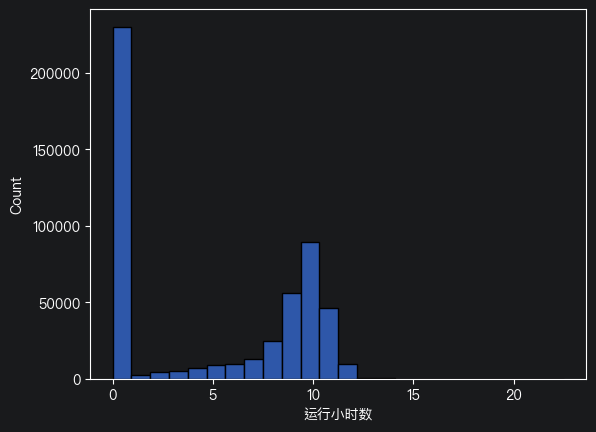

In [213]:
sns.histplot(milage_df_clean['运行小时数'],  bins=24)

In [214]:
milage_df_clean

,日期,班次,设备名称,公司,小时数仪表开始,小时数仪表结束,运行小时数,公里数仪表开始,公里数仪表结束,运行里程,趟数,备注
0,2019-08-26,Day,TEREX TR100 #56 /CHU/,TTJV,131.4,131.4,0.0,1200.7,1200.7,0.0,0.0,NaN
1,2019-08-26,Day,TEREX TR100 #57 /CHU/,TTJV,188.3,197.8,9.5,1672.8,1769.0,96.2,14.0,NaN
2,2019-08-26,Day,TEREX TR100 #58 /CHU/,TTJV,186.1,195.0,8.9,1772.0,1877.0,105.0,16.0,NaN
3,2019-08-26,Day,TEREX TR100 #59 /CHU/,TTJV,189.9,195.2,5.3,1701.2,1752.0,50.8,7.0,NaN
4,2019-08-26,Day,TEREX TR100 #60 /CHU/,TTJV,191.5,201.4,9.9,1742.5,1839.0,96.5,15.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
506817,2026-04-30,Night,TEREX TR100W #1209,Normount,13794.5,13794.5,0.0,0.0,0.0,0.0,0.0,Засвар
506818,2026-04-30,Night,TEREX TR100W #1210,Normount,16527.1,16527.1,0.0,0.0,0.0,0.0,0.0,Засвар
506819,2026-04-30,Night,WT #1211,Normount,3572.0,3579.3,7.3,0.0,0.0,0.0,0.0,худаг20-1 баяжуулах-2
506820,2026-04-30,Night,WT#1212,Normount,1137.5,1137.5,0.0,0.0,0.0,0.0,0.0,NaN


### 保存

In [215]:
milage_df_clean.to_excel('Resources/运距_clean.xlsx', index=False)